# Project Overview Notebook

This notebook summarizes the project using **background, objectives, methods, and conclusions** with **tables, figures, scores, and formulas**.


## 1) Background

Cascading failures in power systems can propagate from local disturbances to large-scale outages.
A core challenge is **cross-topology generalization**: models that work on one network may fail on unseen networks.

We focus on a practical pipeline for:
- early warning (classification), and
- continuous risk assessment (regression),

under strict **Leave-One-Network-Out (LONO)** evaluation.


## 2) Objectives

1. Build robust early-warning classifiers under topology shift.
2. Build regression models for continuous risk scoring.
3. Use informative v2 data construction and threshold calibration for deployment utility.
4. Produce reproducible paper-ready outputs.


## 3) Methods (with formulas)

### LONO split
For each network \(n_k\):

\[
\mathcal{D}_{train}^{(k)} = igcup_{n \in \mathcal{N} \setminus \{n_k\}} \mathcal{D}_{n},\qquad
\mathcal{D}_{test}^{(k)} = \mathcal{D}_{n_k}
\]

### Robust normalization
\[
	ilde{x} = rac{x - \mathrm{median}(x)}{\mathrm{IQR}(x) + \epsilon}
\]

### Threshold decision
\[
\hat{y} = \mathbb{1}[p \ge 	heta]
\]


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Image

ROOT = Path.cwd()
OUT = ROOT / 'analysis' / 'training'
print('ROOT:', ROOT)
print('training dir exists:', OUT.exists())

ROOT: /Users/jumiray/Projects/power-graph-risk-learning
training dir exists: True


## 4) Core scores (table)


In [2]:
main_csv = OUT / 'paper_main_results_final.csv'
if main_csv.exists():
    df = pd.read_csv(main_csv)
    display(df)
else:
    # fallback summary from known converged metrics
    df = pd.DataFrame([
        {'metric':'AUC','value':0.7444},
        {'metric':'AP','value':0.1405},
        {'metric':'F1','value':0.1662},
        {'metric':'Precision','value':0.1331},
        {'metric':'Recall','value':0.4534},
        {'metric':'MAE','value':0.0130},
        {'metric':'RMSE','value':0.0313},
    ])
    display(df)


,section,threshold,auc,ap,f1,precision,recall,mae,rmse,r2
0,classification_final,0.12,0.744428,0.140459,0.166235,0.133084,0.453364,NaN,NaN,NaN
1,regression_final,NaN,NaN,NaN,NaN,NaN,NaN,0.012956,0.031314,-41.158832


## 5) Figures


**fig_pca_network_distribution.png**

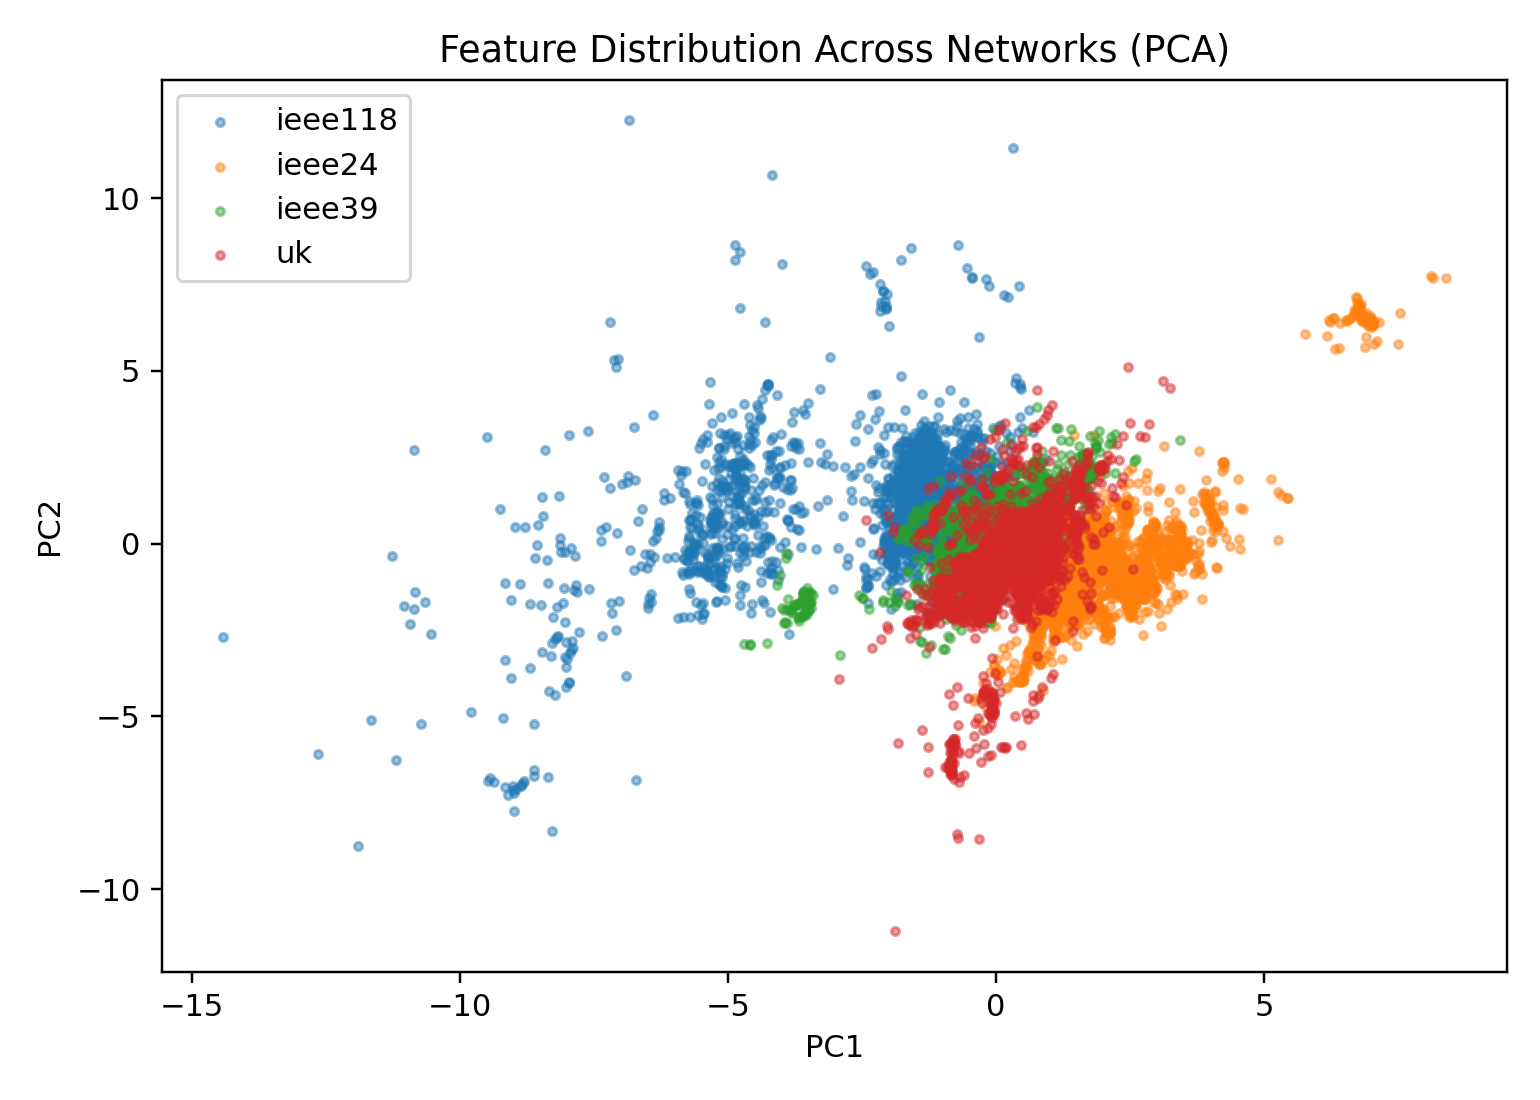

**fig_risk_distribution.png**

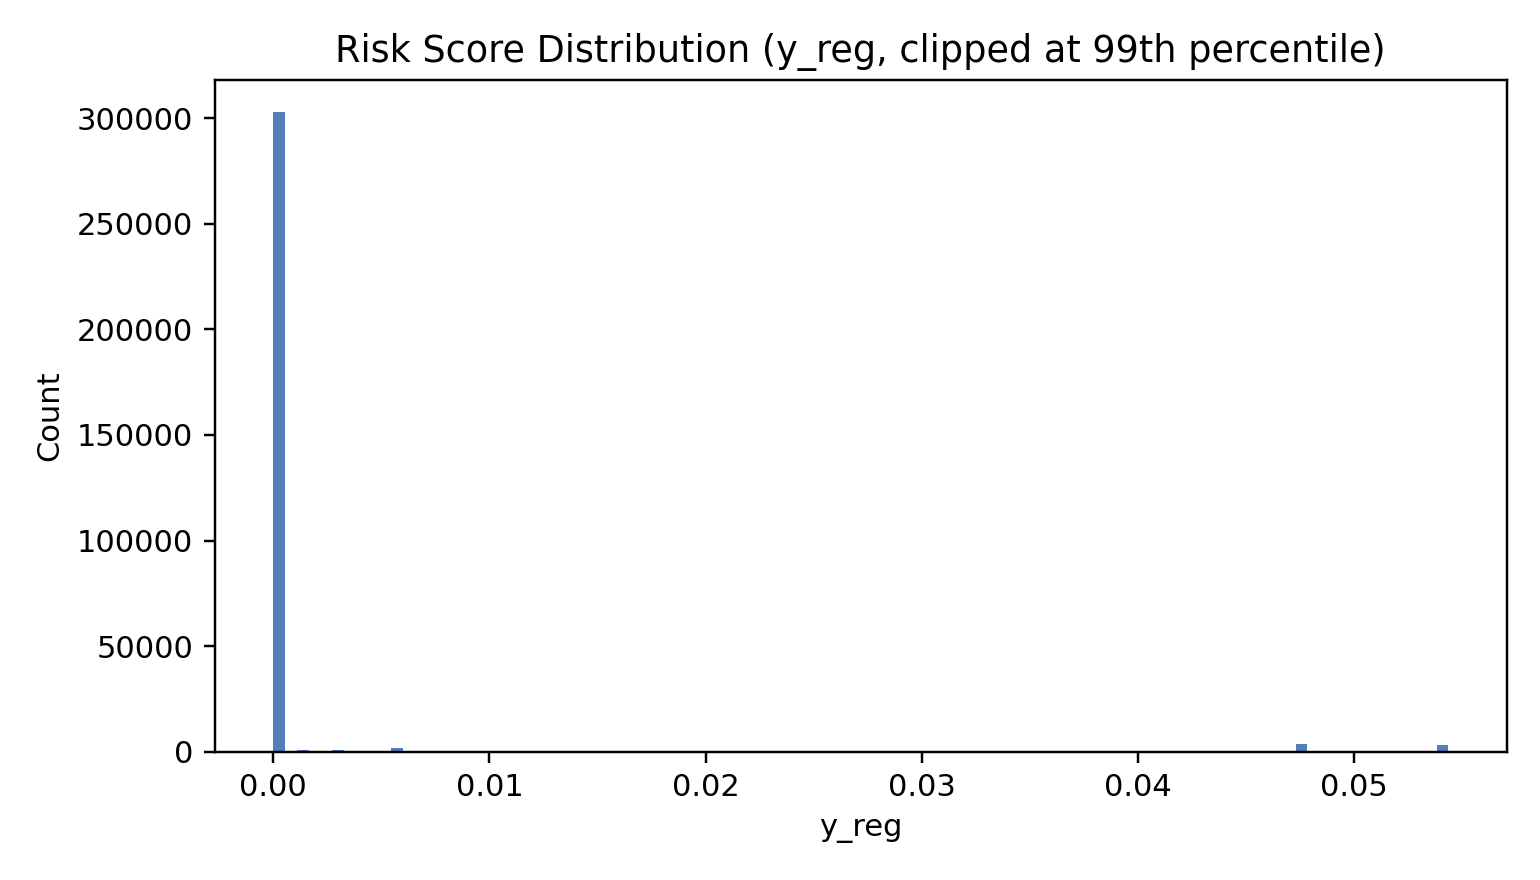

**fig_roc_pr.png**

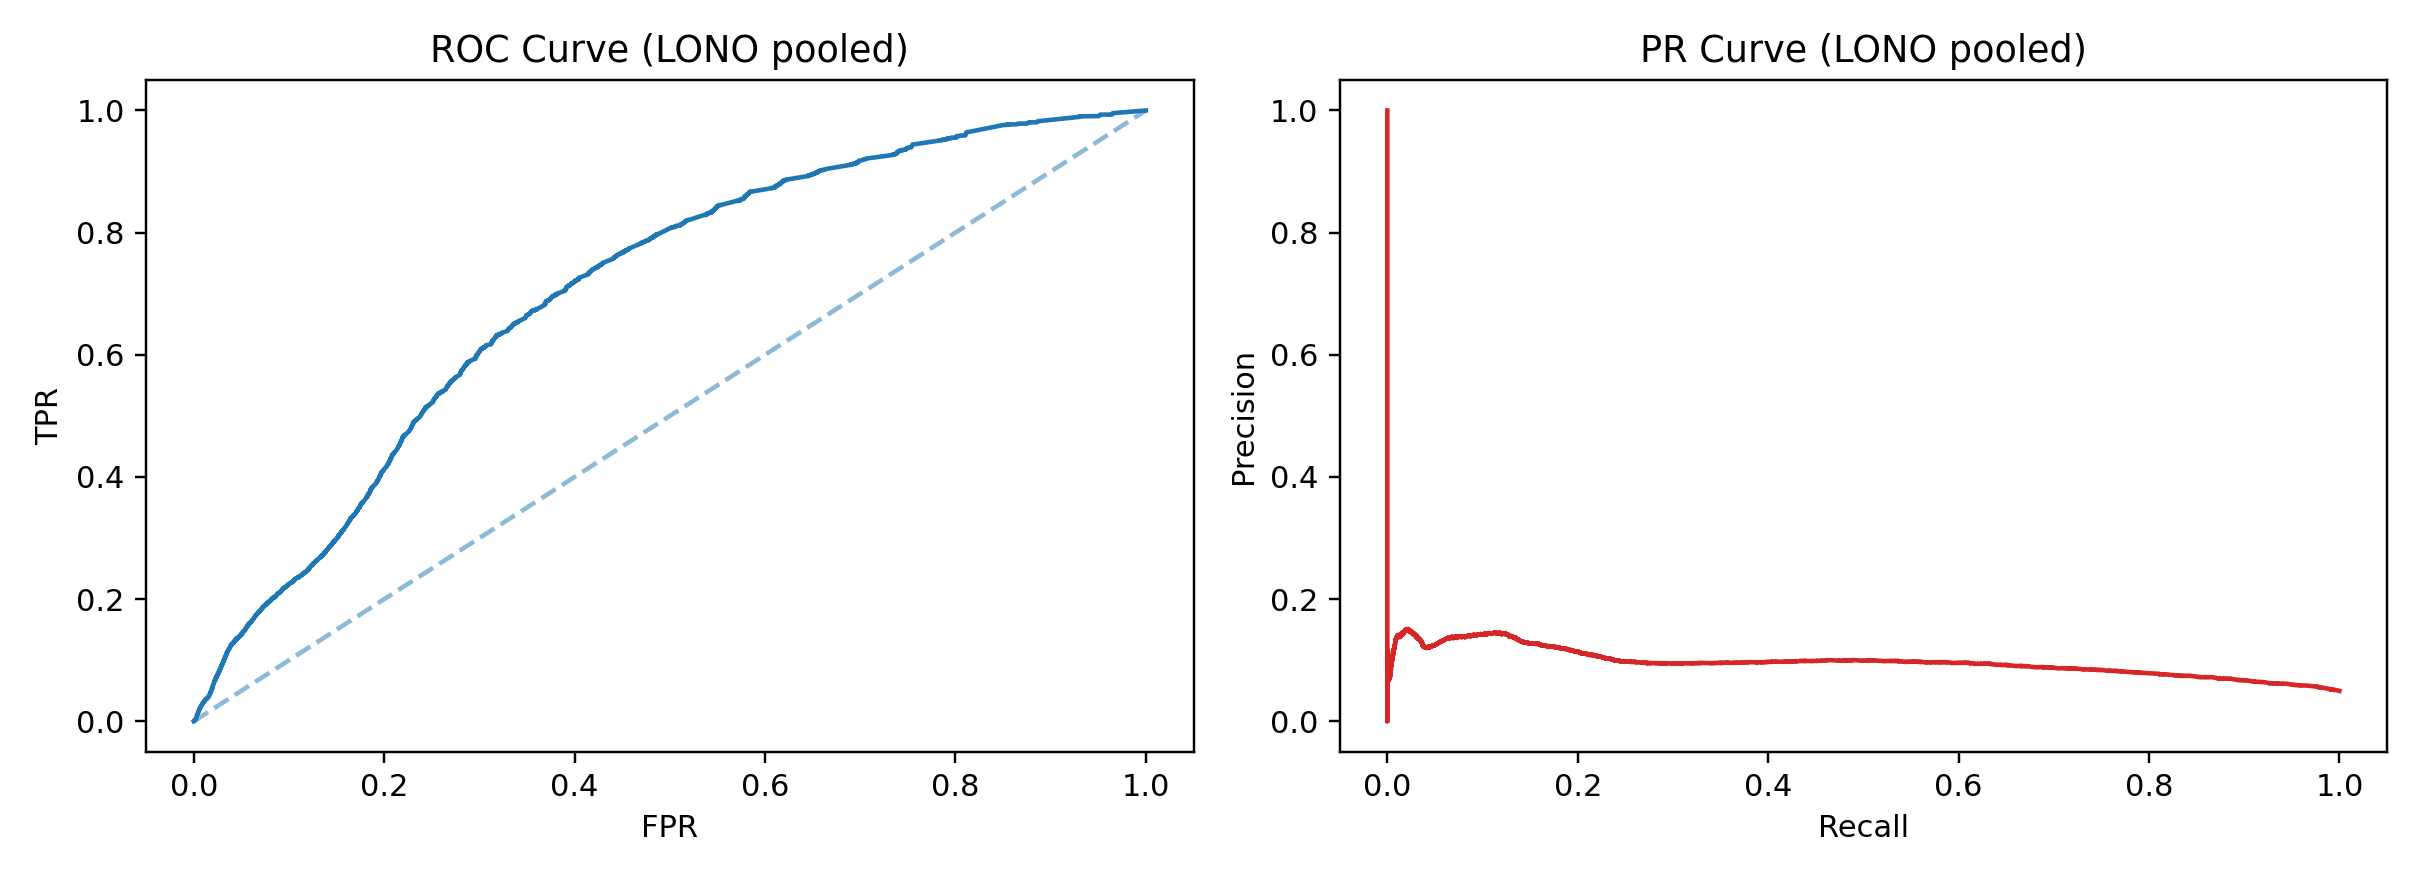

In [3]:
fig_candidates = [
    ROOT / 'documents' / 'figures' / 'fig_pca_network_distribution.png',
    ROOT / 'documents' / 'figures' / 'fig_risk_distribution.png',
    ROOT / 'documents' / 'figures' / 'fig_roc_pr.png',
]
for p in fig_candidates:
    if p.exists():
        display(Markdown(f'**{p.name}**'))
        display(Image(filename=str(p), width=760))
    else:
        print('Missing:', p)


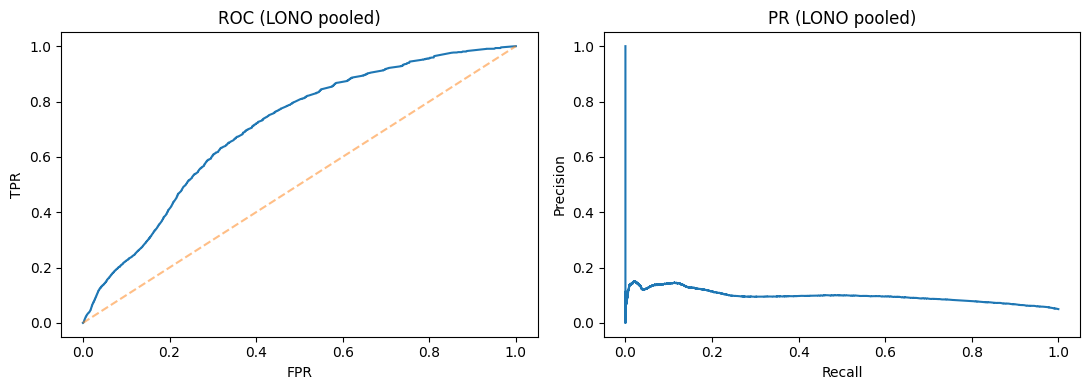

In [4]:
# Optional: plot ROC/PR from exported curve files
roc_csv = OUT / 'paper_roc_curve.csv'
pr_csv = OUT / 'paper_pr_curve.csv'

if roc_csv.exists() and pr_csv.exists():
    roc = pd.read_csv(roc_csv)
    pr = pd.read_csv(pr_csv)
    fig, ax = plt.subplots(1,2, figsize=(11,4))
    ax[0].plot(roc['fpr'], roc['tpr'])
    ax[0].plot([0,1],[0,1],'--',alpha=0.5)
    ax[0].set_title('ROC (LONO pooled)')
    ax[0].set_xlabel('FPR'); ax[0].set_ylabel('TPR')

    ax[1].plot(pr['recall'], pr['precision'])
    ax[1].set_title('PR (LONO pooled)')
    ax[1].set_xlabel('Recall'); ax[1].set_ylabel('Precision')
    plt.tight_layout(); plt.show()
else:
    print('ROC/PR CSV not found.')


## 6) Summary

- The project converges to a practical mainline: **v2 informative dataset + threshold calibration**.
- Under strict LONO, the pipeline achieves stable transfer-oriented performance.
- Outputs are reproducible and ready for thesis/paper packaging.
